In [123]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
from vocoder_behavioural import vocoder_behavioural
from filter_df2 import filter_df2

In [208]:
fs = int(24e3)
seconds = 3
myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()  # Wait until recording is finished
sf.write('test_24hz.wav', myrecording, fs)
plt.plot(myrecording)

In [176]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
from vocoder_behavioural import vocoder_behavioural


def record(fs, seconds=3):
    fs = int(fs)
    myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
    sd.wait()  # Wait until recording is finished
    plt.plot(myrecording)

def get_test_signal(name: str):
    myrecording, fs = sf.read(name, dtype='float32')
    return myrecording, fs

def test_sinusoid(A, fs, phi, f0, n):
    return A*np.cos(2*np.pi*(f0/fs)*n+phi)

def fbands_log(fmin, fmax, n_bands):
    bin_min = np.geomspace(fmin, fmax, n_bands+1)
    return [[bin_min[i], bin_min[i+1]] for i in range(len(bin_min)-1)]

def fbands_log_claude(fmin, fmax, n_bands, octaves=1):
    centers = np.geomspace(fmin, fmax, n_bands)
    octaves_list = np.broadcast_to(octaves, (n_bands,))
    return centers, octaves_list

def fbands_formant(f1=(300, 800), f2=(800, 2500), f3=(2500, 5000)):
    """
    Three bands targeting speech formant regions:
      F1 300-800 Hz  — vowel openness (ah vs ee)
      F2 800-2500 Hz — vowel colour (front vs back)
      F3 2500-5000 Hz — consonant character (s, f, sh)
    """
    return [list(f1), list(f2), list(f3)]



def band_coeffs_iir(fs, fbands, Norder=2):
    b = [np.array(sig.iirfilter(N = Norder, Wn=band, btype='bandpass', output='ba', fs=fs))[0] for band in fbands]
    a = [np.array(sig.iirfilter(N = Norder, Wn=band, btype='bandpass', output='ba', fs=fs))[1] for band in fbands]
    return b, a

def band_coeffs_butter(fs, fbands, Norder=1):
    b = [sig.butter(Norder, band, btype='band', fs=fs)[0] for band in fbands]
    a = [sig.butter(Norder, band, btype='band', fs=fs)[1] for band in fbands]
    return b, a

def low_pass_coeffs_iir(fs, order, cutoff): 
    b, a = np.array(sig.iirfilter(N = order, Wn=cutoff, btype='lowpass', output='ba', fs=fs)) 
    return b, a

def sawtooth(x, fs, carrier_hz=120, duty=0.5):
    samples = len(x)
    saw_periods = int(carrier_hz*samples/fs)
    n = np.linspace(0, saw_periods*2*np.pi, samples)
    return sig.sawtooth(n, duty)

def envelope_follow(band_sig, fs, attack_ms=5, release_ms=80):
    band_sig = np.asarray(band_sig, dtype=np.float64).flatten()
    a = np.exp(-1 / (attack_ms  * 1e-3 * fs))
    r = np.exp(-1 / (release_ms * 1e-3 * fs))
    env = np.zeros(len(band_sig))
    for i in range(1, len(band_sig)):
        v = abs(band_sig[i])
        c = a if v > env[i-1] else r
        env[i] = c * env[i-1] + (1 - c) * v
    return env


In [211]:
x, fs = get_test_signal('test_24hz.wav')

# Generate band segments 

# fbands = fbands_log(fmin=500, fmax=7000, n_bands=3)
fbands = fbands_formant()

# Generate bandpass filters 
bp_b, bp_a = band_coeffs_butter(fs, fbands, Norder=1)

mic_bands = [filter_df2(bp_b[i], bp_a[i], x=x) for i in range(len(bp_a))]

# Low pass filter coefficients
lp_b, lp_a = low_pass_coeffs_iir(fs, order=1, cutoff=50)

# # Envelope extraction for each band
envs = [filter_df2(lp_b, lp_a, np.abs(band)) for band in mic_bands]
# envs = [envelope_follow(band, fs, attack_ms=2, release_ms=120) for band in mic_bands]



pitch = sawtooth(x, fs, carrier_hz=250, duty=0.5)

# Filter pitch through each band
pitch_bands = [filter_df2(bp_b[i], bp_a[i], x=pitch) for i in range(len(bp_a))]

# Combine: sum envelope-modulated pitch bands
out_myfilter = np.sum([env * pitch_band for env, pitch_band in zip(envs, pitch_bands)], axis=0)

plt.plot(out_myfilter)


sd.play(100*out_myfilter, fs)

# fbands = fbands_log(fmin=300, fmax=7000, n_bands=16)
# bp_b, bp_a = band_coeffs_butter(fs, fbands, Norder=2)
# lp_b, lp_a = low_pass_coeffs_iir(fs, order=1, cutoff=20)


In [ ]:
def detect_pitch(x, fs, frame_ms=40, fmin=80, fmax=400):
    """
    Autocorrelation pitch detector.
    Returns estimated fundamental frequency (Hz) for each frame.
    fmin/fmax set the search range — 80-400 Hz covers most voices.
    Returns 0 for unvoiced/silent frames.
    """
    x = np.asarray(x, dtype=np.float64).flatten()
    frame_len = int(frame_ms * 1e-3 * fs)
    min_lag = int(fs / fmax)  # shortest period = highest frequency
    max_lag = int(fs / fmin)  # longest period  = lowest  frequency

    n_frames = len(x) // frame_len
    pitches = np.zeros(n_frames)

    for i in range(n_frames):
        frame = x[i*frame_len : (i+1)*frame_len]
        frame = frame * np.hanning(len(frame))          # window reduces edge artifacts
        corr = np.correlate(frame, frame, mode='full')[len(frame)-1:]
        search = corr[min_lag:max_lag]
        # Only accept peak if it's at least 1% of zero-lag energy (voiced check)
        if len(search) > 0 and corr[0] > 0 and np.max(search) > 0.01 * corr[0]:
            lag = np.argmax(search) + min_lag
            pitches[i] = fs / lag
    return pitches


def sawtooth_tracked(pitches, frame_len, n_samples, fs, duty=0.5):
    """
    Sawtooth carrier with per-frame pitch from detect_pitch().
    Phase accumulator keeps transitions glitch-free.
    Unvoiced frames (pitch==0) output silence.
    """
    pitch_per_sample = np.repeat(pitches, frame_len)[:n_samples]
    phase = np.cumsum(2 * np.pi * pitch_per_sample / fs) % (2 * np.pi)
    out = sig.sawtooth(phase, duty)
    out[pitch_per_sample == 0] = 0  # silence unvoiced frames
    return out


In [ ]:
# ── Pitch-tracking vocoder ────────────────────────────────────────────────────
# Reuses: x, fs, bp_b, bp_a, lp_b, lp_a from the pipeline cell above

frame_ms  = 40
frame_len = int(frame_ms * 1e-3 * fs)

print("Detecting pitch...")
pitches = detect_pitch(x, fs, frame_ms=frame_ms)
voiced   = pitches[pitches > 0]
print(f"  Pitch range : {voiced.min():.0f} – {voiced.max():.0f} Hz")
print(f"  Mean pitch  : {voiced.mean():.0f} Hz")
print(f"  Voiced frames: {len(voiced)}/{len(pitches)}")

# Tracked carrier
n_samples = len(x.flatten())
pitch_carrier = sawtooth_tracked(pitches, frame_len, n_samples, fs).reshape(x.shape)

# Vocoder pipeline — identical to above, only carrier changes
mic_bands_pt   = [filter_df2(bp_b[i], bp_a[i], x=x)             for i in range(len(bp_a))]
envs_pt        = [filter_df2(lp_b, lp_a, np.abs(band))           for band in mic_bands_pt]
pitch_bands_pt = [filter_df2(bp_b[i], bp_a[i], x=pitch_carrier)  for i in range(len(bp_a))]

out_tracked = np.sum([env * pb for env, pb in zip(envs_pt, pitch_bands_pt)], axis=0)

# Plot pitch contour + output
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), tight_layout=True)
ax1.plot(pitches, color='steelblue')
ax1.set_title('Detected pitch per frame (Hz)')
ax1.set_ylabel('Hz')
ax1.grid(True, alpha=0.3)
ax2.plot(out_tracked, color='tomato', linewidth=0.5)
ax2.set_title('Pitch-tracked vocoder output')
ax2.grid(True, alpha=0.3)
plt.show()

sd.play(10 * out_tracked, fs)


In [ ]:
from scipy.signal import butter, tf2sos

# Print SOS coefficients for vocoder_fixed_point_formant.py
print(f"FS = {fs}")
print()
for i, (b, a) in enumerate(zip(bp_b, bp_a)):
    sos = tf2sos(b, a)
    flo, fhi = fbands[i]
    print(f"# Band {i+1}: {flo}-{fhi} Hz")
    print(f"    ({flo:5d}, {fhi:5d}): np.array([{sos.tolist()}]),")
    print()

print("# Envelope LPF")
print(f"lp_b = {list(lp_b)}")
print(f"lp_a = {list(lp_a)}")
print()
import numpy as np
ENV_FC = 20.0
ENV_ALPHA = float(np.exp(-2.0 * np.pi * ENV_FC / fs))
print(f"# ENV_ALPHA = {ENV_ALPHA:.10f}  (ENV_FC={ENV_FC} Hz)")


In [186]:
sd.play(10*x, fs)

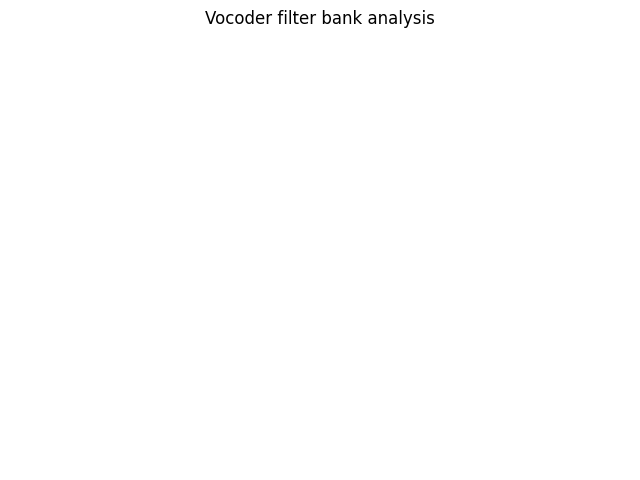

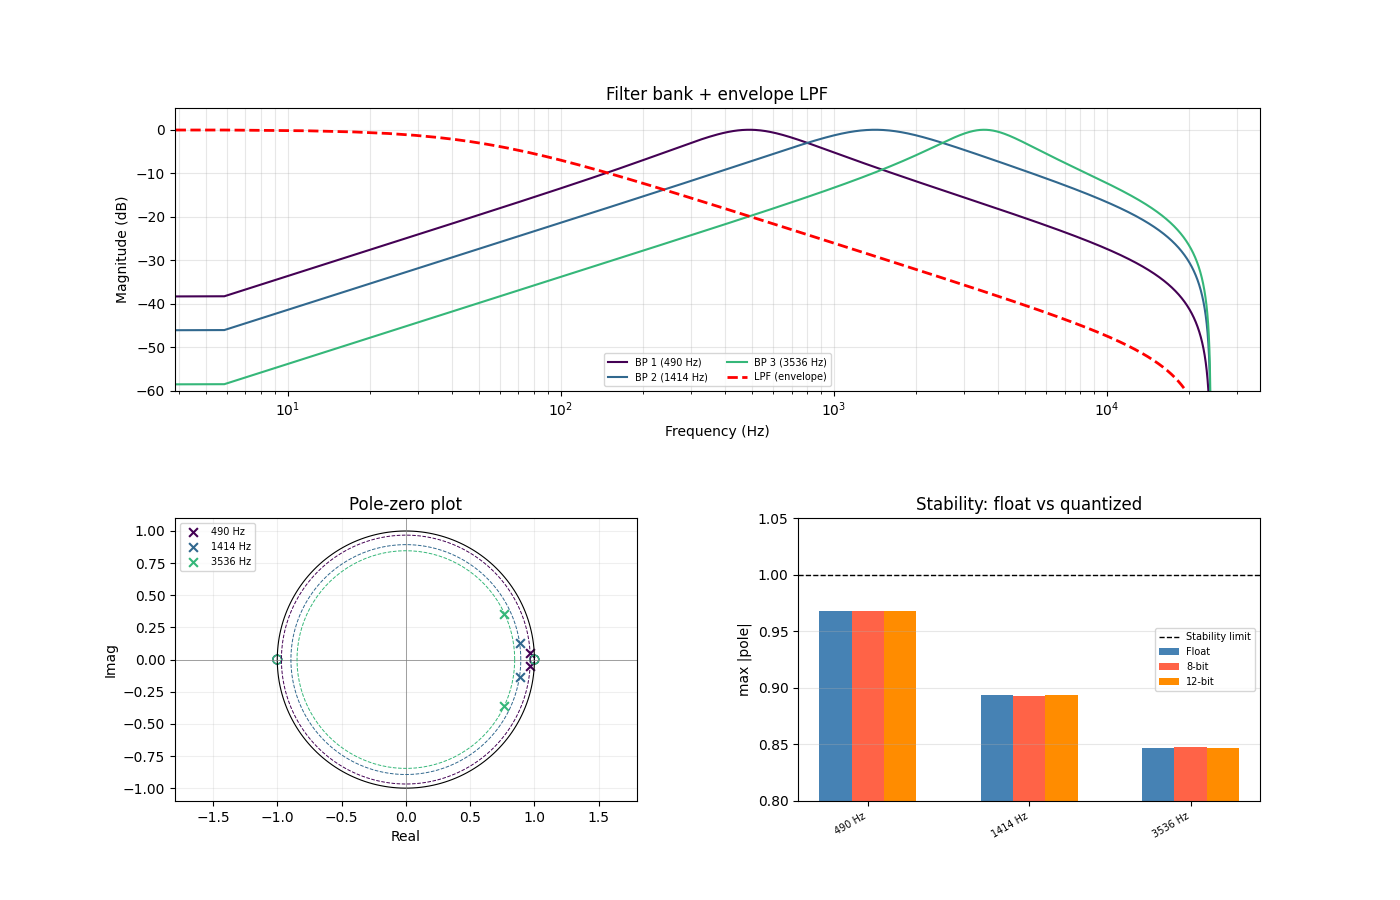

In [205]:
# Plot from Claude 
from scipy.signal import freqz, tf2zpk

# Derive centers and n_bands from fbands edge pairs
centers_plot = [np.sqrt(band[0] * band[1]) for band in fbands]  # geometric mean of edges
n_bands_plot = len(fbands)

bit_configs = [(8, 'tomato'), (12, 'darkorange')]
colors = [plt.cm.viridis(i / n_bands_plot) for i in range(n_bands_plot)]
theta = np.linspace(0, 2*np.pi, 200)

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)
ax_mag  = fig.add_subplot(gs[0, :])
ax_pz   = fig.add_subplot(gs[1, 0])
ax_stab = fig.add_subplot(gs[1, 1])

# --- Magnitude response: bandpass bands + envelope LPF ---
for i, (b, a) in enumerate(zip(bp_b, bp_a)):
    w, h = freqz(b, a, worN=4096, fs=fs)
    ax_mag.plot(w, 20*np.log10(np.abs(h) + 1e-12), color=colors[i], label=f'BP {i+1} ({centers_plot[i]:.0f} Hz)')

w_lp, h_lp = freqz(lp_b, lp_a, worN=4096, fs=fs)
ax_mag.plot(w_lp, 20*np.log10(np.abs(h_lp) + 1e-12), 'r--', linewidth=2, label='LPF (envelope)')
ax_mag.set_xscale('log')
ax_mag.set_ylim(-60, 5)
ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.set_xlabel('Frequency (Hz)')
ax_mag.set_title('Filter bank + envelope LPF')
ax_mag.legend(fontsize=7, ncol=2)
ax_mag.grid(True, alpha=0.3, which='both')

# --- Pole-zero plot ---
ax_pz.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=0.8)
ax_pz.axhline(0, color='grey', linewidth=0.5)
ax_pz.axvline(0, color='grey', linewidth=0.5)

for i, (b, a) in enumerate(zip(bp_b, bp_a)):
    z, p, k = tf2zpk(b, a)
    r = max(np.abs(p))
    ax_pz.plot(r*np.cos(theta), r*np.sin(theta), '--', color=colors[i], linewidth=0.7)
    ax_pz.scatter(p.real, p.imag, marker='x', color=colors[i], s=40, label=f'{centers_plot[i]:.0f} Hz')
    ax_pz.scatter(z.real, z.imag, marker='o', facecolors='none', edgecolors=colors[i], s=40)

ax_pz.set_title('Pole-zero plot')
ax_pz.set_xlabel('Real')
ax_pz.set_ylabel('Imag')
ax_pz.legend(fontsize=7, loc='upper left')
ax_pz.axis('equal')
ax_pz.grid(True, alpha=0.2)

# --- Stability: float vs 8-bit and 12-bit quantized ---
max_p_float = []
max_p_quant = {bits: [] for bits, _ in bit_configs}

for b, a in zip(bp_b, bp_a):
    _, p, _ = tf2zpk(b, a)
    max_p_float.append(max(np.abs(p)))
    for bits, _ in bit_configs:
        scale = 2 ** (bits - 1)
        b_q = np.round(b * scale) / scale
        a_q = np.round(a * scale) / scale
        _, p_q, _ = tf2zpk(b_q, a_q)
        max_p_quant[bits].append(max(np.abs(p_q)))

n_configs = len(bit_configs)
bar_width = 0.2
x_pos = np.arange(n_bands_plot)

ax_stab.bar(x_pos - (n_configs / 2) * bar_width, max_p_float, bar_width, label='Float', color='steelblue')
for j, (bits, color) in enumerate(bit_configs):
    offset = (j - n_configs / 2 + 1) * bar_width
    ax_stab.bar(x_pos + offset, max_p_quant[bits], bar_width, label=f'{bits}-bit', color=color)

ax_stab.axhline(1.0, color='k', linestyle='--', linewidth=1, label='Stability limit')
ax_stab.set_xticks(x_pos)
ax_stab.set_xticklabels([f'{c:.0f} Hz' for c in centers_plot], rotation=30, ha='right', fontsize=7)
ax_stab.set_ylabel('max |pole|')
ax_stab.set_title('Stability: float vs quantized')
ax_stab.set_ylim(0.8, 1.05)
ax_stab.legend(fontsize=7)
ax_stab.grid(True, alpha=0.3, axis='y')

plt.figure()
plt.suptitle('Vocoder filter bank analysis', fontsize=12)
plt.show()


interactive(children=(IntSlider(value=0, description='X min', max=143999, step=100), IntSlider(value=144000, d…

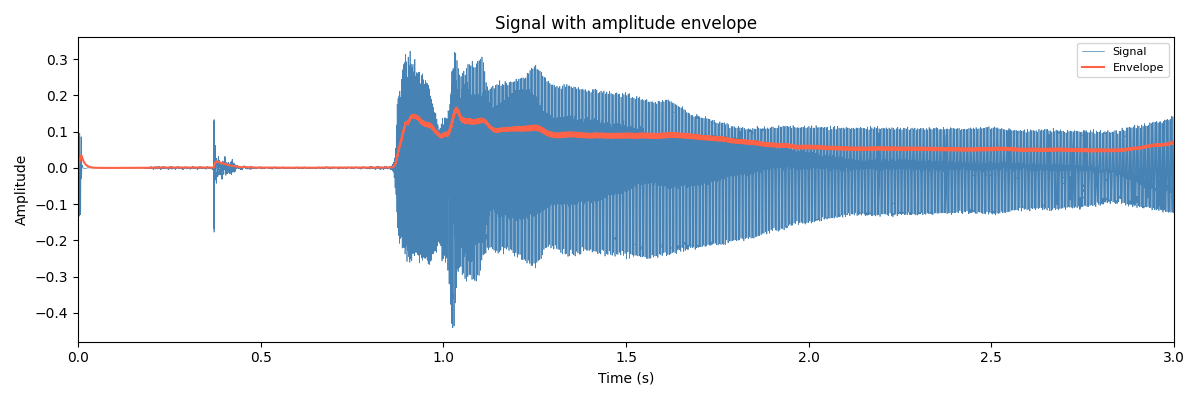

In [127]:
%matplotlib widget
from ipywidgets import interact, IntSlider

x_flat = x.flatten()
t = np.arange(len(x_flat)) / fs  # time in seconds

# Overall amplitude envelope using existing LPF coefficients
amplitude_envelope = sig.lfilter(lp_b, lp_a, np.abs(x_flat))

fig, ax = plt.subplots(figsize=(12, 4), tight_layout=True)
ax.set_title('Signal with amplitude envelope')
ax.set_ylabel('Amplitude')
ax.set_xlabel('Time (s)')

line_sig, = ax.plot(t, x_flat,             color='steelblue', linewidth=0.5, label='Signal')
line_env, = ax.plot(t, amplitude_envelope, color='tomato',    linewidth=1.5, label='Envelope')
ax.legend(fontsize=8)

def update(x_min, x_max):
    if x_min < x_max:
        ax.set_xlim(x_min / fs, x_max / fs)
        fig.canvas.draw_idle()

interact(update,
    x_min = IntSlider(min=0, max=len(t)-1, step=100, value=0,        description='X min'),
    x_max = IntSlider(min=1, max=len(t),   step=100, value=len(t),   description='X max'))
plt.show()


In [161]:
from importlib import reload
import vocoder_hq
reload(vocoder_hq)
from vocoder_hq import vocoder_hq

x, fs = get_test_signal('test.wav')

# Classic "YouTube vocoder" — C major chord carrier
out_hq = vocoder_hq(x, fs, carrier_notes=[130.81, 196.00, 261.63], filter_order=1)
sd.play(1e1*out_hq, fs)

# Try other chords:
# Minor: [261.63, 311.13, 392.00]
# Power chord: [130.81, 196.00, 261.63]
# Single robot voice: [120]


Read in test signal 

# Use model to check output

In [79]:
out = np.array(vocoder_behavioural(x=myrecording, a1=iir_a1, a2=iir_a2, a3=iir_a3, b1=iir_b1, b2=iir_b2, b3=iir_b3, saw_periods=100))

# Butterworth Claude Suggestion

In [109]:
import numpy as np
from scipy.signal import butter

fs = 48000
n_bands = 4
centers = np.geomspace(300, 5e3, n_bands)

# One octave value per band, or a single scalar applied to all bands
octaves = [2.5, 1.5, 1.5, 1.5, 1, 1, 1, 1]  # wider bandwidth on lowest band

def band_coeffs(fc, fs, octaves=1):
    factor = 2 ** (octaves / 2)
    f_low  = fc / factor
    f_high = min(fc * factor, fs*0.499)
    b, a = butter(1, [f_low, f_high], btype='band', fs=fs)
    return b, a


coeffs = [band_coeffs(fc, fs, octaves=oct) for fc, oct in zip(centers, octaves)]


In [28]:
1/5000

0.0002

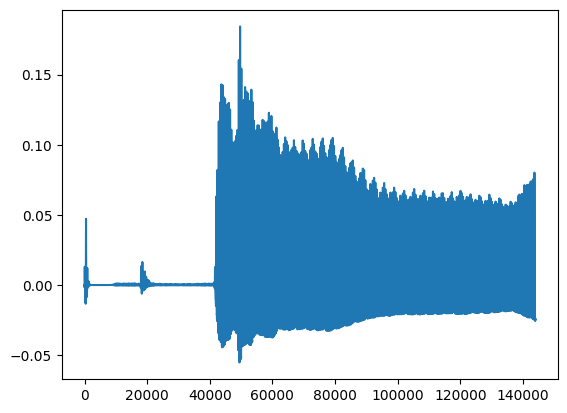

In [110]:
import numpy as np
from scipy.signal import butter

fs = 48000
n_bands = 4
centers = np.geomspace(300, 5e3, n_bands)

# One octave value per band, or a single scalar applied to all bands
octaves = [2.5, 1.5, 1.5, 1.5, 1, 1, 1, 1]  # wider bandwidth on lowest band

def band_coeffs(fc, fs, octaves=1):
    factor = 2 ** (octaves / 2)
    f_low  = fc / factor
    f_high = min(fc * factor, fs*0.499)
    b, a = butter(1, [f_low, f_high], btype='band', fs=fs)
    return b, a


coeffs = [band_coeffs(fc, fs, octaves=oct) for fc, oct in zip(centers, octaves)]

x = myrecording

# Unpack generated coefficients
band_bs = [b for b, a in coeffs]
band_as = [a for b, a in coeffs]

# Filter mic through each band
mic_bands = [filter_df2(b, a, x=x) for b, a in zip(band_bs, band_as)]

lpfb, lpfa = np.array(sig.iirfilter(N = 1, Wn=30, btype='lowpass', output='ba', fs=fs)) 

# Envelope extraction for each band
envs = [filter_df2(lpfb, lpfa, np.abs(band)) for band in mic_bands]

# Generate sawtooth
saw_periods = 360
samples = len(x)
n = np.linspace(0, saw_periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)

# Filter pitch through each band
pitch_bands = [filter_df2(b, a, x=pitch) for b, a in zip(band_bs, band_as)]

# Combine: sum envelope-modulated pitch bands
out_myfilter = np.sum([env * pitch_band for env, pitch_band in zip(envs, pitch_bands)], axis=0)

plt.plot(out_myfilter)

In [101]:
sd.play(1e1*out_myfilter, fs)

In [31]:
sd.play(myrecording, fs)

# Stability and Size

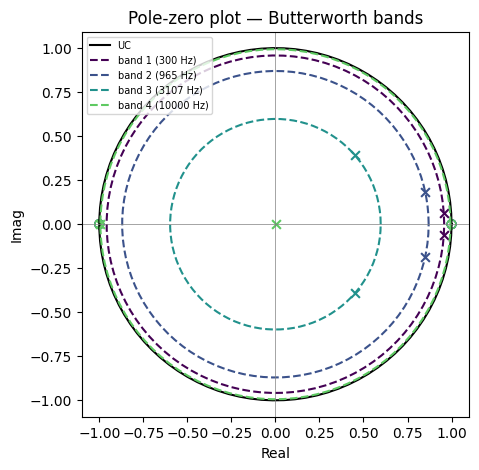

In [165]:
# Extract poles and zeros from Butterworth coeffs and plot on complex plane
zpk_bands = [sig.tf2zpk(b, a) for b, a in coeffs]

theta = np.linspace(0, np.pi*2, 100)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linestyle='-', color='k', label='UC')

for i, (z, p, k) in enumerate(zpk_bands):
    label = f'band {i+1} ({centers[i]:.0f} Hz)'
    color = plt.cm.viridis(i / len(zpk_bands))
    # Pole radius circle (matches existing plot style)
    r = max(np.abs(p))
    plt.plot(r*np.cos(theta), r*np.sin(theta), linestyle='--', color=color, label=label)
    # Actual poles and zeros
    plt.scatter(p.real, p.imag, marker='x', color=color, s=40)
    plt.scatter(z.real, z.imag, marker='o', facecolors='none', edgecolors=color, s=40)

plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.legend(fontsize=7, loc='upper left')
plt.title('Pole-zero plot — Butterworth bands')
plt.xlabel('Real')
plt.ylabel('Imag')
plt.axis('equal')
plt.show()

In [1]:
from scipy.signal import tf2zpk

# Quantize coefficients to N bits then recheck poles
bits = 8
scale = 2**(bits-1)

for i, (b, a) in enumerate(coeffs):
    b_q = np.round(b * scale) / scale    # quantize
    a_q = np.round(a * scale) / scale
    z, p, k = tf2zpk(b_q, a_q)
    max_pole = max(np.abs(p))
    stable = "OK" if max_pole < 1.0 else "UNSTABLE"
    print(f"Band {i+1} ({centers[i]:.0f} Hz): max|p| = {max_pole:.6f}  [{stable}]")


NameError: name 'coeffs' is not defined

In [88]:
for i, (z, p, k) in enumerate(zpk_bands):
    print(f"Band {i+1} ({centers[i]:.0f} Hz): poles = {p}, max|p| = {max(np.abs(p)):.6f}")


Band 1 (300 Hz): poles = [0.97791211+0.05363437j 0.97791211-0.05363437j 0.99038867+0.02436118j
 0.99038867-0.02436118j], max|p| = 0.990688
Band 2 (533 Hz): poles = [0.95906296+0.0937753j  0.95906296-0.0937753j  0.98255383+0.04299643j
 0.98255383-0.04299643j], max|p| = 0.983494
Band 3 (949 Hz): poles = [0.92223115+0.16165219j 0.92223115-0.16165219j 0.96786396+0.07541724j
 0.96786396-0.07541724j], max|p| = 0.970798
Band 4 (1687 Hz): poles = [0.93939498+0.13072076j 0.93939498-0.13072076j 0.84742191+0.27114634j
 0.84742191-0.27114634j], max|p| = 0.948447
Band 5 (3000 Hz): poles = [0.88167351+0.22114119j 0.88167351-0.22114119j 0.69069024+0.43012173j
 0.69069024-0.43012173j], max|p| = 0.908984


In [83]:
for i, (z, p, k) in enumerate(zpk_bands):
    print(f"Band {i+1} ({centers[i]:.0f} Hz): poles = {p}, max|p| = {max(np.abs(p)):.6f}")


Band 1 (100 Hz): poles = [0.99291337+0.01813357j 0.99291337-0.01813357j 0.99685345+0.00817198j
 0.99685345-0.00817198j], max|p| = 0.996887
Band 2 (376 Hz): poles = [0.97192624+0.06686558j 0.97192624-0.06686558j 0.9878703 +0.03046332j
 0.9878703 -0.03046332j], max|p| = 0.988340
Band 3 (1414 Hz): poles = [0.87634759+0.23236923j 0.87634759-0.23236923j 0.95025893+0.11064485j
 0.95025893-0.11064485j], max|p| = 0.956679
Band 4 (5318 Hz): poles = [0.75991331+0.35284124j 0.75991331-0.35284124j 0.36549826+0.59980842j
 0.36549826-0.59980842j], max|p| = 0.837834
Band 5 (20000 Hz): poles = [-0.99555719+0.00445069j -0.99555719-0.00445069j  0.00647568+0.4160256j
  0.00647568-0.4160256j ], max|p| = 0.995567


In [ ]:
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for i, (b, a) in enumerate(coeffs):
    w, h = sig.freqz(b, a, worN=4096, fs=fs)
    color = plt.cm.viridis(i / len(coeffs))
    label = f'band {i+1} ({centers[i]:.0f} Hz)'
    ax_mag.plot(w, 20 * np.log10(np.abs(h) + 1e-12), color=color, label=label)
    ax_phase.plot(w, np.unwrap(np.angle(h)) * 180 / np.pi, color=color, label=label)

ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.set_ylim(-60, 5)
ax_mag.legend(fontsize=8)
ax_mag.grid(True, alpha=0.3)
ax_mag.set_title('Filter bank frequency response')

ax_phase.set_ylabel('Phase (degrees)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.legend(fontsize=8)
ax_phase.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


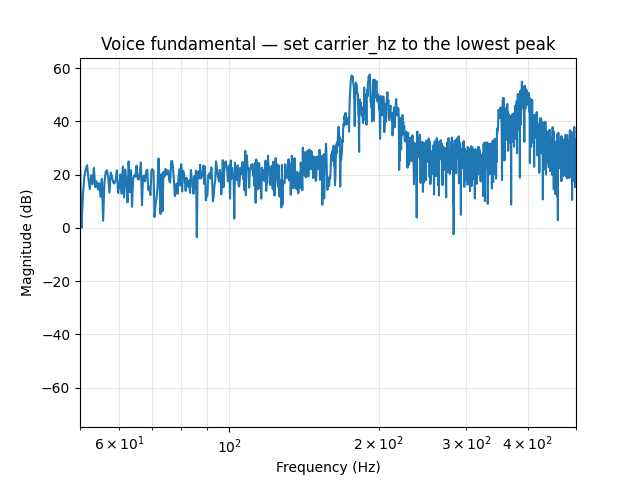

In [182]:
X = np.fft.rfft(x.flatten())
freqs = np.fft.rfftfreq(len(x.flatten()), 1/fs)

plt.figure()
plt.plot(freqs, 20*np.log10(np.abs(X) + 1e-9))
plt.xscale('log')
plt.xlim(50, 500)   # zoom into the fundamental range
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Voice fundamental — set carrier_hz to the lowest peak')
plt.grid(True, which='both', alpha=0.3)
plt.show()


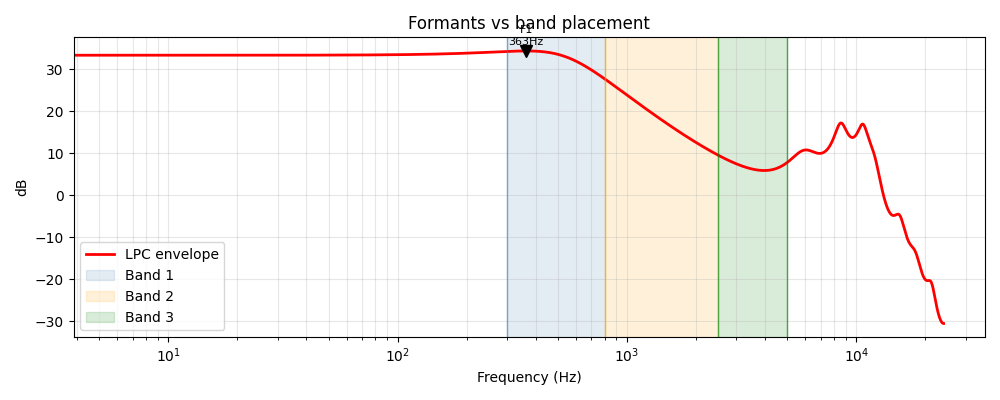

In [198]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(w_lpc, H_lpc, 'r', linewidth=2, label='LPC envelope')

# Shade each band with alternating colours
band_colors = ['steelblue', 'orange', 'green']
for i, (band, color) in enumerate(zip(fbands, band_colors)):
    ax.axvspan(band[0], band[1], alpha=0.15, color=color, label=f'Band {i+1}')
    ax.axvline(band[0], color=color, linewidth=1, alpha=0.6)
ax.axvline(fbands[-1][1], color=band_colors[-1], linewidth=1, alpha=0.6)

# Label detected formants
for i, f in enumerate(formant_freqs):
    idx = np.argmin(np.abs(w_lpc - f))
    ax.plot(f, H_lpc[idx], 'kv', markersize=8)
    ax.text(f, H_lpc[idx] + 1.5, f'F{i+1}\n{f:.0f}Hz', ha='center', fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('dB')
ax.set_title('Formants vs band placement')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


In [199]:
# Only look for formants within the speech range
speech_range = (w_lpc > 200) & (w_lpc < 4000)
w_speech = w_lpc[speech_range]
H_speech = H_lpc[speech_range]

peaks, props = find_peaks(H_speech, height=np.max(H_speech)-30, distance=20)
peaks = peaks[np.argsort(props['peak_heights'])[::-1]][:4]
formant_freqs = sorted(w_speech[peaks])

print("Detected formants:")
for i, f in enumerate(formant_freqs):
    print(f"  F{i+1}: {f:.0f} Hz")


Detected formants:
  F1: 363 Hz


In [193]:
w_lpc, H_lpc = lpc_envelope(x, order=20)  # higher order for 48kHz signal

speech_range = (w_lpc > 200) & (w_lpc < 4000)
w_speech = w_lpc[speech_range]
H_speech = H_lpc[speech_range]

peaks, props = find_peaks(H_speech, height=np.max(H_speech)-50, distance=10)
peaks = peaks[np.argsort(props['peak_heights'])[::-1]][:4]
formant_freqs = sorted(w_speech[peaks])

print("Detected formants:")
for i, f in enumerate(formant_freqs):
    print(f"  F{i+1}: {f:.0f} Hz")


Detected formants:
  F1: 363 Hz
